# Lecture 8 — Neural Value Function Iteration

**Computational Methods for Heterogeneous-Agent Macro**

Jeffrey Sun

## 1. Setup

In [1]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

using HouseholdStages
using Flux
using Flux: Chain, Dense, swish, Adam, withgradient
using Printf
using Statistics
using LinearAlgebra
using Random: MersenneTwister, seed!
using Plots

  Activating project at `~/projects/teaching/ZJU Computational Macro 2026/tutorial_notebooks`


## 2. The Krusell-Smith setup

The **Krusell-Smith** model is Aiyagari with an **aggregate** Markov process for TFP $A$.

This means that the ``perfect-foresight'' method we used for the MIT shock will no longer work.

With stochastic aggregate productivity $Z_t$, prices $r_t, w_t$ depend on $(Z_t, K_t)$. Now, if the household could anticipate $K_{t+1}$ from $K_t$ alone, then we could treat $K_t$ much like just another idiosyncratic state variable. (This is basically the trick used by so-called ``block-recursive'' models.)

But sadly, no such luck here: In this case, $K_{t+1}$ is the integral of *all* households' savings choices, which (due to heterogeneity) depend on the entire wealth distribution $\Lambda_t$.

So the agent's own state space has to include $\Lambda_t$ to make truly rational (i.e. rational-expectations) decisions:
$$V(b, z; \Lambda, Z) = \max_{c, b'} u(c) + \beta\, \mathbb{E}[V(b', z'; \Lambda', Z') \mid z, Z].$$

But a grid over **all possible values** of $\Lambda_t$ is infeasible. We need some kind of dimension reduction.

Here, we cover two such methods. The latter is my own contribution:

- **§3 — Krusell-Smith (1998):** assume agents track only the first moment $K_t$ and forecast $K_{t+1}$ from a parametric log-linear rule. Solve the implied 4D VFI, simulate, refit the rule. Approximate aggregation makes this work.
- **§4 — CVIAYN:** parameterise $V_\theta(b, z, \Lambda, Z)$ directly with a neural network that conditions on the full distribution $\Lambda$ via a learned generalized moment. Drop the ALM, drop the regression, train against the outer Bellman residual.

This notebook and the previous demonstrate two methods solving the same **Krusell-Smith** model.

nVFI is not dramatically better than the K--S method on the K--S model. Indeed, the K--S method does pretty well! But nVFI is more general.

We start by building the K--S model.

### 2.1 Parameters

In [2]:
@kwdef struct KSParams
    β::Float64 = 0.94
    γ::Float64 = 1.0
    α::Float64 = 0.36
    δ::Float64 = 0.025
    # Idiosyncratic productivity z (unemployed / employed)
    z_grid::Vector{Float64} = [0.07, 1.0]
    Π_z::Matrix{Float64}    = [0.6   0.4;
                               0.05  0.95]
    # Aggregate TFP Z (bad / good)
    Z_vals::Vector{Float64} = [0.99, 1.01]
    Π_Z::Matrix{Float64}    = [0.875 0.125;
                               0.125 0.875]
    # Wealth grid
    N_b::Int       = 80
    b_min::Float64 = 0.0
    b_max::Float64 = 80.0
    # K grid (for the K-S 4D VFI; not used by CVIAYN)
    N_K::Int       = 5
    K_min::Float64 = 6.0
    K_max::Float64 = 10.0
end

KSParams

### 2.2 Prices and effective labour

Cobb-Douglas production with TFP $Z$ and effective labour $L$:
$$R(Z, K) = \alpha\, Z\, (K/L)^{\alpha-1} + 1 - \delta, \qquad w(Z, K) = (1-\alpha)\, Z\, (K/L)^\alpha.$$

Effective labour is the stationary-distribution average of $z$. It is constant in this model since $\Pi_z$ is independent of $Z$.

In [3]:
function markov_stationary_mean(Π_z::AbstractMatrix, z_grid::AbstractVector)
    v = real.(eigvecs(Π_z')[:, end])
    return z_grid ⋅ (v ./ sum(v))
end

function ks_prices(K, Z, p::KSParams)
    L = markov_stationary_mean(p.Π_z, p.z_grid)
    R = p.α * Z * (K/L)^(p.α - 1) + 1 - p.δ
    w = (1 - p.α) * Z * (K/L)^p.α
    return (; R, w)
end

ks_prices (generic function with 1 method)

### 2.3 The inner household chain (3 stages)

The within-period block is the same as Aiyagari: `z_shock ∘ income ∘ savings`.

In [4]:
_u_crra(c, ::Val{1}) = log(c)
_u_crra(c, ::Val{1.0}) = log(c)
_u_crra(c, ::Val{σ}) where σ = (c^(1 - σ)) / (1 - σ)
u_crra(c, valσ::Val) = c < 0 ? -Inf : _u_crra(c, valσ)

"Three-stage household chain: z_shock ∘ income ∘ savings. Prices are read from env."
function ks_household(p::KSParams)
    # Define layout: axis 1 (wealth) is continuous, axis 2 (z) is discrete.
    layout = StateLayout(
        StateAxis(:wealth, continuous_grid(p.b_min, p.b_max; length=p.N_b, spacing=:log)),
        StateAxis(:z, p.z_grid),
    )

    # Define the three stages.
    z_shock = MarkovStage(layout; axis=:z, transition=p.Π_z)
    # Clamp cash-on-hand at b_max: V is then read only on-grid, held at V(b_max) past it
    # (no constant-MV linear right-extrapolation). See §4.x note. Near-empty under this
    # calibration, so it is insurance, not a binding distortion.
    income  = WealthChangeStage(layout; wealth_post=(cell; env) -> min(env.R * cell.wealth + env.w * cell.z, p.b_max))
    savings = ConsumptionSavingsStage(layout; β=p.β, utility=(cell, c; env) -> u_crra(c, Val(p.γ)), monotone_search=:divide_conquer)

    # Build the household chain and define a moment.
    hh = z_shock ∘ income ∘ savings
    return define_moments!(hh; K_supplied=at_end(integrand=:wealth, reduce=sum))
end

ks_household

### 2.4 Deterministic Aiyagari SS at $Z = 1$

Before adding aggregate uncertainty, find the deterministic steady state $\bar K$ at $Z = 1$ using tatonnement.

In [5]:
"""Solve the deterministic Aiyagari steady state at given Z by **bisection** on K.

Equilibrium solves A(K) = K, where A is household asset supply at the prices implied by K.
Bisection (not damped tâtonnement) is used because this calibration sits near the βR≈1
knife-edge, where supply is hyper-sensitive and damped iteration limit-cycles. A(K) is
monotone decreasing in K, so the root is unique and bracketed by [K_lo, K_hi]."""
function aiyagari_steady_state_at_Z(p::KSParams; Z=1.0, K_lo=5.0, K_hi=12.0, rtol=3e-3, maxiter=30, verbosity=0)
    hh = ks_household(p)
    V, Λ = nothing, nothing
    function supply(K)                       # household asset supply A(K), warm-started
        res = solve_steady_state_given_env!(hh, make_env(hh; ks_prices(K, Z, p)...);
                                            V_init=V, Λ_init=Λ, lambda_tol=1e-7, lambda_maxiter=2_000_000)
        V = res.V; Λ = res.Λ
        return res.moments.K_supplied
    end
    lo, hi = K_lo, K_hi
    (supply(lo) - lo > 0 && supply(hi) - hi < 0) ||
        error("aiyagari_steady_state_at_Z: [K_lo, K_hi] = [$K_lo, $K_hi] does not bracket A(K)=K")
    K = (lo + hi) / 2; iters = 0
    for i in 1:maxiter
        K = (lo + hi) / 2
        f = supply(K) - K
        iters = i
        verbosity >= 1 && @printf "  bisect %2d: K = %.4f,  A(K) − K = %+.4f\n" i K f
        abs(f) / K < rtol && break
        f > 0 ? (lo = K) : (hi = K)          # A(K)−K decreasing ⇒ move the right bound
    end
    return (; K, V, Λ, iters)
end

aiyagari_steady_state_at_Z

## 4. Solving via CVIAYN

Here, we train a neural network, $\widehat{V}^{\mathrm{end}}_\theta$, to approximate the value function, conditional on the full population distribution $\Lambda$.

### 4.1 The neural network $V_\theta$: a generalized-moment architecture

We parameterise $V_\theta(b, z, \Lambda, Z)$ with four sub-nets (mirroring Han-Yang-E 2025), whose division of labour is the whole point:

- **`pop_agg_net`** embeds each own-state $(b, z)$ into a `gm_dim`-vector, then averages those embeddings against the population weights $\Lambda$. The result is a **generalized moment** $m(\Lambda) \in \mathbb{R}^{\texttt{gm\_dim}}$ — a *learned*, low-dimensional summary of the entire distribution. This is the only channel through which $\Lambda$ enters, and the bottleneck where dimension reduction actually happens.
- **`V_pre`** maps the own-state $(b, z)$ to a feature vector — the part of $V$ that depends only on the agent's own position.
- **`gm_post`** lifts the generalized moment $m(\Lambda)$ into that same feature space; we add it to the `V_pre` features, so the distribution shifts every cell's features additively.
- **`V_post`** takes the combined features plus a one-hot encoding of the aggregate state $Z$ and reads off $V^{\mathrm{end}}_\theta(b, z; \Lambda, Z)$ at every $(b, z)$ cell at once.

The design encodes the method's central bet: $\Lambda$ matters for individual values *only* through the `gm_dim` generalized moments. Setting `gm_dim` $= 1$ would be close in spirit to Krusell-Smith — track a single summary statistic of the distribution — while a larger `gm_dim` lets the network discover richer summaries if the problem demands them.

In [6]:
p = KSParams()

const N_z = length(p.z_grid)
const N_Z = length(p.Z_vals)

# Pre-build the (2, N_b * N_z) feature matrix once. Each column is the
# normalised (b, z) coordinates of one cell.
function build_hh_feat(p::KSParams)
    b_norm = collect(range(0f0, 1f0; length=p.N_b))
    z_norm = collect(range(0f0, 1f0; length=length(p.z_grid)))
    feat = zeros(Float32, 2, p.N_b * length(p.z_grid))
    col = 1
    for j in 1:length(p.z_grid), i in 1:p.N_b
        feat[1, col] = b_norm[i]
        feat[2, col] = z_norm[j]
        col += 1
    end
    return feat
end

const HH_FEAT = build_hh_feat(p)
const N_CELLS = size(HH_FEAT, 2)

# Pre-build one-hot Z rows for each Z_idx, shape (N_Z, N_CELLS), so we can
# vcat directly with the (mid, N_CELLS) hidden features in V_post.
const Z_ROWS = [repeat(Float32.(1:N_Z .== Z_idx), 1, N_CELLS) for Z_idx in 1:N_Z]

2-element Vector{Matrix{Float32}}:
 [1.0 1.0 … 1.0 1.0; 0.0 0.0 … 0.0 0.0]
 [0.0 0.0 … 0.0 0.0; 1.0 1.0 … 1.0 1.0]

In [7]:
abstract type AbstractVNet end

# `VNet` and the shape-anchored `ShapeVNet` (§5) are both `AbstractVNet`s. Every
# helper below (inner solve, lookahead, sampler, loss, pretrain, train!) is written
# against `AbstractVNet` and uses only the call interface `net(Λ, Z_idx, p)`, so a new
# architecture drops in with no change to the training machinery.
struct VNet{A, P, G, V} <: AbstractVNet
    pop_agg_net :: A    # (b, z) → gm_dim         per-cell embedding for GM
    V_pre       :: P    # (b, z) → mid            per-cell features for V head
    gm_post     :: G    # gm_dim → mid            project GM to mid space
    V_post      :: V    # mid + N_Z → 1           combine + Z, read off V_end
end

function VNet(; gm_dim=16, mid=32, seed=9483, v_bias=20f0)
    seed!(seed)
    pop_agg_net = Chain(Dense(2 => mid, swish), Dense(mid => mid, swish), Dense(mid => gm_dim))
    V_pre       = Chain(Dense(2 => mid, swish), Dense(mid => mid, swish), Dense(mid => mid, swish))
    gm_post     = Chain(Dense(gm_dim => mid), Dense(mid => mid, swish))
    V_post      = Chain(Dense(mid + N_Z => mid, swish), Dense(mid => mid, swish), Dense(mid => 1))
    # Scale init only — sets the output's resting level near V_ss's mean so pretrain
    # starts in the right ballpark. V_ss is NOT a training objective; it never appears
    # in the residual loss (see `bellman_residual_loss` and `train!`).
    V_post.layers[end].bias .= v_bias
    return VNet(pop_agg_net, V_pre, gm_post, V_post)
end

Flux.@layer VNet

function (net::VNet)(Λ::AbstractMatrix, Z_idx::Int, p::KSParams)
    pop_emb = net.pop_agg_net(HH_FEAT)          # (gm_dim, N_CELLS)
    gm      = pop_emb * Float32.(vec(Λ))        # (gm_dim,)   pop-weighted average
    h_pre   = net.V_pre(HH_FEAT)                # (mid, N_CELLS)
    h_gm    = net.gm_post(gm)                   # (mid,)
    h       = h_pre .+ h_gm                     # broadcast → (mid, N_CELLS)
    pred    = net.V_post(vcat(h, Z_ROWS[Z_idx])) # (1, N_CELLS)
    return reshape(pred, p.N_b, length(p.z_grid))
end

### 4.2 One inner solve under $V_\theta$

Given an aggregate state $(\Lambda, Z)$:

1. Evaluate $V_\theta(\Lambda, Z)$ to get an `N_b × N_z` array of $V^{\mathrm{end}}$ values.
2. Build `env` at prices $(R, w) = $ `ks_prices(K(Λ), Z, p)`, where $K(\Lambda) = \int b\, d\Lambda$.
3. One backward sweep through the 3-stage chain `ks_household` returns $V^{\mathrm{start}}$ and seats the savings policy.

This is $\Phi_V$ from the CVIAYN paper.

In [8]:
"Wealth integral against a 2D (b, z) distribution."
function integrate_K(hh, Λ::AbstractMatrix)
    b_grid = axisvalues(input_layout(hh).axes[1])
    return sum(Λ[i, j] * b_grid[i] for i in axes(Λ, 1), j in axes(Λ, 2))
end

"One backward sweep through the 3-stage chain at the given (Λ, Z) under V_θ."
function inner_solve_backward(hh, vnet::AbstractVNet, Λ::AbstractMatrix, Z_idx::Int, p::KSParams)
    V_end = Float64.(vnet(Λ, Z_idx, p))
    env   = make_env(hh; ks_prices(integrate_K(hh, Λ), p.Z_vals[Z_idx], p)...)
    return backward!(hh, V_end, env)
end

ss = aiyagari_steady_state_at_Z(p; verbosity=1)
K_bar, Λ_ss, V_ss = ss.K, ss.Λ, ss.V
hh = ks_household(p)

vnet = VNet()
V0 = vnet(Λ_ss, 1, p)
@printf "VNet output at (Λ_ss, Z=1): shape = %s, range = [%.3f, %.3f]\n" string(size(V0)) minimum(V0) maximum(V0)

V_start_demo = inner_solve_backward(hh, vnet, Λ_ss, 1, p)
@printf "Inner backward at (Λ_ss, Z=bad): V_start shape = %s, range = [%.3f, %.3f]\n" string(size(V_start_demo)) minimum(V_start_demo) maximum(V_start_demo)

  bisect  1: K = 8.5000,  A(K) − K = -3.6213
  bisect  2: K = 6.7500,  A(K) − K = +17.6769
  bisect  3: K = 7.6250,  A(K) − K = +1.0257
  bisect  4: K = 8.0625,  A(K) − K = -0.2134
  bisect  5: K = 7.8438,  A(K) − K = +0.0198
VNet output at (Λ_ss, Z=1): shape = (80, 2), range = [19.963, 19.999]
Inner backward at (Λ_ss, Z=bad): V_start shape = (80, 2), range = [17.464, 23.149]


### 4.3 The lookahead operator $\mathcal{L} V_\theta$

For a single sampled $\Lambda^{\mathrm{start}}_i$ with aggregate index $Z_i$:

1. Evaluate $V_\theta(\Lambda^{\mathrm{start}}_i, Z_i)$ to get $V^{\mathrm{end}}$ — the agent's current belief about end-of-period continuation values.
2. Push $\Lambda^{\mathrm{start}}_i$ forward one period through $\Phi$ to get $\Lambda^{\mathrm{end}}_i$.
3. For each next-period aggregate state $Z_{\mathrm{next}}$, run $\Phi_V$ at $(\Lambda^{\mathrm{end}}_i, Z_{\mathrm{next}})$ to get $V^{\mathrm{start}}_{\mathrm{next}}$.
4. Take expectation over $Z_{\mathrm{next}}$ using $\Pi_Z[Z_i, \cdot]$.

In this setup $\Omega(\Lambda^{\mathrm{end}}, Z')$ is the identity — the aggregate shock $Z'$ affects next-period prices but not $\Lambda$ at the period boundary. So $\Lambda^{\mathrm{start}}_{i+1} = \Lambda^{\mathrm{end}}_i$. The result is the **lookahead label** $\widehat{V}^{\mathrm{end}}_i \equiv (\mathcal{L} V_\theta)(\Lambda^{\mathrm{start}}_i, Z_i)$.

In [9]:
"Compute the lookahead label LV_θ(Λ_start, Z). Returns V_end_label and Λ_end."
function lookahead(hh, vnet::AbstractVNet, Λ_start::AbstractMatrix, Z_idx::Int, p::KSParams)
    # Continuation here is `vnet` itself — V_θ as a moving fixed point. V_ss does NOT
    # appear and must not appear: dropping it back in would smuggle the warm start
    # into the training target and turn this from nVFI into "fit to deterministic V_ss".
    V_end_now = Float64.(vnet(Λ_start, Z_idx, p))
    env_now   = make_env(hh; ks_prices(integrate_K(hh, Λ_start), p.Z_vals[Z_idx], p)...)
    backward!(hh, V_end_now, env_now)                  # seats savings policy
    Λ_end = forward!(hh, Λ_start)

    V_end_label = zeros(Float64, p.N_b, length(p.z_grid))
    for Z_next in 1:N_Z
        V_start_next = inner_solve_backward(hh, vnet, Λ_end, Z_next, p)
        V_end_label .+= p.Π_Z[Z_idx, Z_next] .* V_start_next
    end
    return (; V_end_label, Λ_end)
end

lookahead

### 4.4 Outer Bellman residual loss

For a batch of samples $\{(\Lambda^{\mathrm{start}}_i, Z_i)\}$, compute the lookahead label $\widehat{V}^{\mathrm{end}}_i$ once *outside* `withgradient`, then fit $V_\theta$ to it in mean-square. This is the standard semi-gradient treatment — we don't differentiate through $\Phi$.

In [10]:
"Run the lookahead operator on each sample. Returns a vector of (Λ, Z_idx, target) tuples."
function build_targets(hh, vnet::AbstractVNet, batch, p::KSParams)
    targets = NamedTuple{(:Λ, :Z_idx, :target), Tuple{Matrix{Float64}, Int, Matrix{Float32}}}[]
    for (Λ_start, Z_idx) in batch
        out = lookahead(hh, vnet, Λ_start, Z_idx, p)
        push!(targets, (; Λ=copy(Λ_start), Z_idx, target=Float32.(out.V_end_label)))
    end
    return targets
end

"Plain mean-squared outer Bellman residual on a batch of (Λ, Z, target) tuples."
function bellman_residual_loss(vnet::AbstractVNet, targets, p::KSParams)
    # `target` is the lookahead label LV_θ produced from V_θ itself — NOT V_ss.
    # V_ss is a warm start, not a training objective; it must never appear here.
    #
    # No variance normalisation. Under Adam the loss scale is nearly irrelevant
    # (the update g/√(g²) is scale-invariant), so dividing by the target variance
    # mostly rescaled the printed number, not the optimisation. Dropping it keeps the
    # loss a transparent mean-squared residual in V² units.
    L = 0f0
    for (Λ, Z_idx, target) in targets
        pred = vnet(Λ, Z_idx, p)
        L   += sum((pred .- target).^2) / length(pred)
    end
    return L / length(targets)
end

bellman_residual_loss

### 4.5 Sampling $\Lambda^{\mathrm{start}}$ by MCMC

Simulate the model under the *current* $V_\theta$, discard burn-in, subsample. The sampler tracks the network — early in training, samples are drawn from the trajectory induced by an under-trained network; the distribution improves with $\theta$.

In [11]:
"Sample Z_{t+1} | Z_t from the aggregate Markov chain."
function sample_Z(Z_idx, Π_Z, rng)
    u = rand(rng)
    s = 0.0
    for j in eachindex(view(Π_Z, Z_idx, :))
        s += Π_Z[Z_idx, j]
        u <= s && return j
    end
    return size(Π_Z, 2)
end

"Simulate one period forward under V_θ at realised (Λ_t, Z_t). Reseats the savings policy."
function sim_one_step(hh, vnet::AbstractVNet, Λ::AbstractMatrix, Z_idx::Int, p::KSParams)
    V_end = Float64.(vnet(Λ, Z_idx, p))
    env   = make_env(hh; ks_prices(integrate_K(hh, Λ), p.Z_vals[Z_idx], p)...)
    backward!(hh, V_end, env)
    return forward!(hh, Λ)
end

"MCMC-style sample of (Λ_start, Z) along the ergodic path induced by V_θ."
function sample_ergodic(hh, vnet::AbstractVNet, p::KSParams; T=800, burn=400, every=4, rng=MersenneTwister(8421))
    Λ     = copy(Λ_ss)
    Z_idx = 1
    batch = Tuple{Matrix{Float64}, Int}[]
    for t in 1:T
        Λ     = sim_one_step(hh, vnet, Λ, Z_idx, p)
        Z_idx = sample_Z(Z_idx, p.Π_Z, rng)
        if t > burn && (t - burn) % every == 0
            push!(batch, (copy(Λ), Z_idx))
        end
    end
    return batch
end

sample_ergodic

### 4.6 Pretrain on the deterministic $V_{\mathrm{ss}}(Z)$

A randomly-initialised $V_\theta$ often produces within-period solves that fail numerically (consumption tries to go off-grid, savings policy degenerates). The cheap fix: pretrain $V_\theta(\cdot, Z)$ to match the deterministic-SS value function **at that $Z$**, $V_{\mathrm{ss}}(Z)$, across a cloud of $\Lambda$'s.

We solve the deterministic Aiyagari SS *once per $Z$*, giving two arrays $V_{\mathrm{ss}}(0.99)$ and $V_{\mathrm{ss}}(1.01)$, and pretrain $V_\theta(\Lambda, Z) \to V_{\mathrm{ss}}(Z)$ separately for each $Z$.

**Why one target per $Z$, rather than a single $Z$-invariant $V_{\mathrm{ss}}$?** Pretraining all $Z$'s to one common target would actively teach $V_{\text{post}}$ to ignore its $Z$ one-hot input. After 300 epochs of that, the $Z$-conditioning weights are dead, and the downstream Bellman-residual gradient is too weak to revive them — $V_\theta$ ends up $Z$-flat and training oscillates rather than converging.

The point is *not* that $V_{\mathrm{ss}}(Z)$ is the right answer at any $\Lambda$ — it isn't, except by coincidence at $\Lambda = \Lambda_{\mathrm{ss}}$ (and even then only at the right $Z$). The point is that it's a sensible $Z$-aware baseline, which gets the network into the right scale, shape, *and* Z-conditioning before real training begins.

In [12]:
"Multiplicative-noise perturbation of Λ with renormalisation."
function perturb_Λ(Λ::AbstractMatrix, σ, rng)
    Λp = Λ .* (1 .+ σ .* randn(rng, size(Λ)))
    Λp = max.(Λp, 0)
    return Λp ./ sum(Λp)
end

"Pretrain V_θ on Z-conditional V_ss(Z) replicated across a Λ-cloud. Returns the loss history."
function pretrain_to_ss!(vnet::AbstractVNet, V_ss_per_Z::Vector{<:AbstractMatrix}, p::KSParams;
                          epochs=300, lr=5e-3, n_Λ=6, σ=0.10, seed=4747)
    # WARM START ONLY: the deterministic V_ss(Z) touch parameters here and nowhere
    # else — never as a regularizer or anchor downstream, or we smuggle K-S-style
    # approximations back into nVFI. (See §4.6 for why one target PER Z.)
    opt     = Flux.setup(Adam(lr), vnet)
    targets = [Float32.(V) for V in V_ss_per_Z]
    rng     = MersenneTwister(seed)
    hist    = Float64[]
    for epoch in 1:epochs
        Λ_cloud = [perturb_Λ(Λ_ss, σ, rng) for _ in 1:n_Λ]
        loss, grads = withgradient(vnet) do net
            L = 0f0
            for Λ in Λ_cloud, Z_idx in 1:N_Z
                pred = net(Λ, Z_idx, p)
                L += sum((pred .- targets[Z_idx]).^2)
            end
            L / (n_Λ * N_Z * length(targets[1]))
        end
        Flux.update!(opt, vnet, grads[1])
        push!(hist, Float64(loss))
    end
    return hist
end

# Solve the deterministic Aiyagari SS at each Z separately. Each V_ss(Z) becomes
# the pretrain target for that Z, giving the network a real Z signal to lock onto.
println("Solving deterministic Aiyagari SS at each Z (for Z-conditional pretrain target)...")
V_ss_per_Z = [aiyagari_steady_state_at_Z(p; Z=Zv).V for Zv in p.Z_vals]
for (i, Zv) in enumerate(p.Z_vals)
    @printf "  Z=%.2f: V range = [%.2f, %.2f]\n" Zv minimum(V_ss_per_Z[i]) maximum(V_ss_per_Z[i])
end

println("Pretraining V_θ on Z-conditional V_ss(Z) across a Λ-cloud...")
@time pre_hist = pretrain_to_ss!(vnet, V_ss_per_Z, p; epochs=300)
@printf "Pretrain loss: %.4e → %.4e (over %d epochs)\n" pre_hist[1] pre_hist[end] length(pre_hist)
# V_ss(Z) has now done its one job. From here on, the training signal is the Bellman
# residual against the lookahead label LV_θ — V_ss(Z) does not appear downstream.

Solving deterministic Aiyagari SS at each Z (for Z-conditional pretrain target)...
  Z=0.99: V range = [-0.38, 29.00]
  Z=1.01: V range = [0.23, 29.01]
Pretraining V_θ on Z-conditional V_ss(Z) across a Λ-cloud...
 51.572296 seconds (61.10 M allocations: 5.911 GiB, 2.81% gc time, 84.36% compilation time: <1% of which was recompilation)
Pretrain loss: 1.3834e+02 → 3.7421e-02 (over 300 epochs)


### 4.7 The training loop

One epoch = sample a fresh batch of $\Lambda$ under the current $V_\theta$, compute the lookahead labels $\widehat{V}^{\mathrm{end}}_i = (\mathcal{L} V_\theta)(\Lambda_i, Z_i)$ with the gradient stopped, and take **one small Adam step** fitting $V_\theta$ to them. This is neural **fitted value iteration**: regress the network onto its own Bellman image, and repeat.

Because the label is built from $V_\theta$ itself, the update is *semi-gradient* — a large step would chase its own moving target and oscillate. A **small learning rate** ($3\times10^{-5}$) keeps it stable: $V_\theta$ moves so little per epoch that the labels are quasi-static, so each step is essentially a supervised regression onto a near-fixed target. We are also sampling on-policy under a discounted — hence *contracting* — Bellman operator, the benign regime for this kind of bootstrapping. The price is a few thousand epochs; the payoff is a loop with nothing in it but a network, a mean-squared loss, and a small step. $V_{\mathrm{ss}}$ does not appear — the only signal is $\lVert V_\theta - \mathcal{L} V_\theta\rVert^2$.

In [13]:
"Neural fitted value iteration. Each epoch: sample a batch under the current V_θ,
recompute the lookahead labels ℒV_θ (stop-gradient), take one small Adam step toward
them. A small learning rate is what keeps this semi-gradient update stable — see §4.7."
function train!(vnet::AbstractVNet, hh, p::KSParams; epochs=4_000, lr=3e-5, T=200, burn=100, every=4)
    # Plain loop: one net, mean-squared loss, small constant step. The small lr keeps
    # the semi-gradient update stable (§4.7). V_ss does not appear — the signal is the
    # Bellman residual ‖V_θ − ℒV_θ‖² against labels from V_θ itself.
    opt  = Flux.setup(Adam(Float32(lr)), vnet)
    hist = Float64[]
    rng  = MersenneTwister(1729)
    for epoch in 1:epochs
        # Sample under the live net, build labels from the same live net (stop-gradient
        # is automatic: build_targets runs outside `withgradient`).
        batch   = sample_ergodic(hh, vnet, p; T, burn, every, rng=MersenneTwister(rand(rng, UInt32)))
        targets = build_targets(hh, vnet, batch, p)
        loss, grads = withgradient(vnet) do net
            bellman_residual_loss(net, targets, p)
        end
        Flux.update!(opt, vnet, grads[1])
        push!(hist, Float64(loss))
        (epoch == 1 || epoch % 50 == 0) &&
            @printf "  epoch %4d / %4d: loss = %.4e (batch = %d)\n" epoch epochs loss length(batch)
    end
    return hist
end

train!

### 4.8 Run training loop

**NOTE:** We are using a small neural network for demonstration purposes.

In [14]:
train_hist = train!(vnet, hh, p; epochs=4_000)

  epoch    1 / 4000: loss = 3.1886e-02 (batch = 25)
  epoch   50 / 4000: loss = 1.8876e-02 (batch = 25)
  epoch  100 / 4000: loss = 1.4169e-02 (batch = 25)
  epoch  150 / 4000: loss = 1.3297e-02 (batch = 25)
  epoch  200 / 4000: loss = 1.2859e-02 (batch = 25)
  epoch  250 / 4000: loss = 1.2195e-02 (batch = 25)
  epoch  300 / 4000: loss = 1.1806e-02 (batch = 25)
  epoch  350 / 4000: loss = 1.1682e-02 (batch = 25)
  epoch  400 / 4000: loss = 1.0837e-02 (batch = 25)
  epoch  450 / 4000: loss = 1.0600e-02 (batch = 25)
  epoch  500 / 4000: loss = 1.0347e-02 (batch = 25)
  epoch  550 / 4000: loss = 1.0689e-02 (batch = 25)
  epoch  600 / 4000: loss = 9.7618e-03 (batch = 25)
  epoch  650 / 4000: loss = 9.6790e-03 (batch = 25)
  epoch  700 / 4000: loss = 1.0598e-02 (batch = 25)
  epoch  750 / 4000: loss = 9.2612e-03 (batch = 25)
  epoch  800 / 4000: loss = 9.2474e-03 (batch = 25)
  epoch  850 / 4000: loss = 9.2173e-03 (batch = 25)
  epoch  900 / 4000: loss = 9.3613e-03 (batch = 25)
  epoch  950

4000-element Vector{Float64}:
 0.03188588470220566
 0.03182601556181908
 0.03102847747504711
 0.030516166239976883
 0.030597815290093422
 0.03001461550593376
 0.029184000566601753
 0.028010766953229904
 0.027335645630955696
 0.026245437562465668
 ⋮
 0.005382162518799305
 0.005732960067689419
 0.006001031957566738
 0.00542435422539711
 0.005793055519461632
 0.005376485176384449
 0.005379527807235718
 0.005349240265786648
 0.005260631442070007

### 4.9 Reading the loss curve

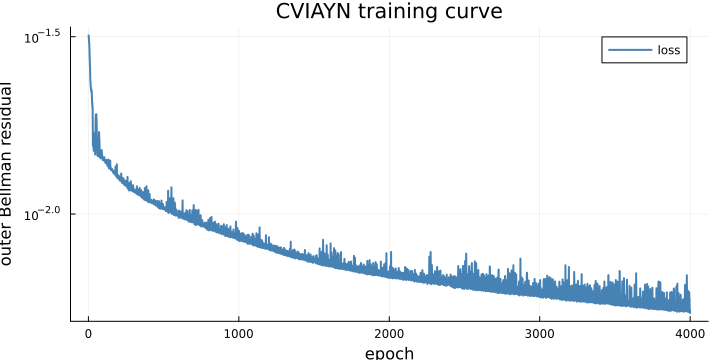

In [15]:
plot(train_hist; yaxis=:log, lw=2, color=:steelblue,
     xlabel="epoch", ylabel="outer Bellman residual",
     title="CVIAYN training curve",
     label="loss", size=(720, 360), legend=:topright)

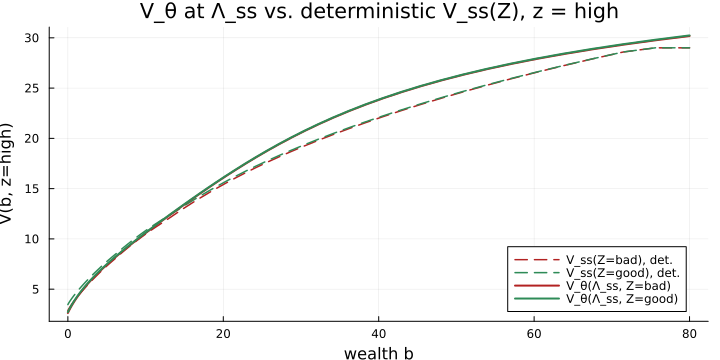

In [16]:
b_grid = axisvalues(input_layout(hh).axes[1])

plt = plot(; xlabel="wealth b", ylabel="V(b, z=high)",
           title="V_θ at Λ_ss vs. deterministic V_ss(Z), z = high",
           size=(720, 360), legend=:bottomright)

# Deterministic V_ss at each Z (dashed) — reference, NOT a training target.
plot!(plt, b_grid, V_ss_per_Z[1][:, end]; lw=1.5, color=:firebrick, ls=:dash, label="V_ss(Z=bad), det.")
plot!(plt, b_grid, V_ss_per_Z[2][:, end]; lw=1.5, color=:seagreen, ls=:dash, label="V_ss(Z=good), det.")

# Trained V_θ at Λ_ss for each Z (solid).
plot!(plt, b_grid, vnet(Λ_ss, 1, p)[:, end]; lw=2, color=:firebrick, label="V_θ(Λ_ss, Z=bad)")
plot!(plt, b_grid, vnet(Λ_ss, 2, p)[:, end]; lw=2, color=:seagreen, label="V_θ(Λ_ss, Z=good)")

plt

### 4.10 Comparison with the Krusell-Smith method

As a check, we compare $V_\theta(\Lambda_{\mathrm{ss}}, Z)$ against the Krusell-Smith behavioural value $V_{\mathrm{KS}}(\cdot, K(\Lambda_{\mathrm{ss}}), Z)$ from L07, evaluated at the stationary distribution.

Running K-S outer iteration...
 23.569738 seconds (430.98 M allocations: 23.500 GiB, 13.55% gc time, 18.71% compilation time)
Converged ALM:
  Z = bad : log K' = +0.2188 + +0.8936 log K
  Z = good: log K' = +0.1886 + +0.9104 log K
K(Λ_ss) = 7.864, interpolated between K[2]=7.00 (weight 0.136) and K[3]=8.00

at z = high:
  |V_θ - V_KS| (Z=bad) : mean = +0.3193, rms = 0.7418, max = 1.7200
  |V_θ - V_KS| (Z=good): mean = +0.3026, rms = 0.7417, max = 1.7105
  V_KS Z-gap (good-bad): mean = +0.0737, max = +0.1140
  V_θ  Z-gap (good-bad): mean = +0.0570, max = +0.0907


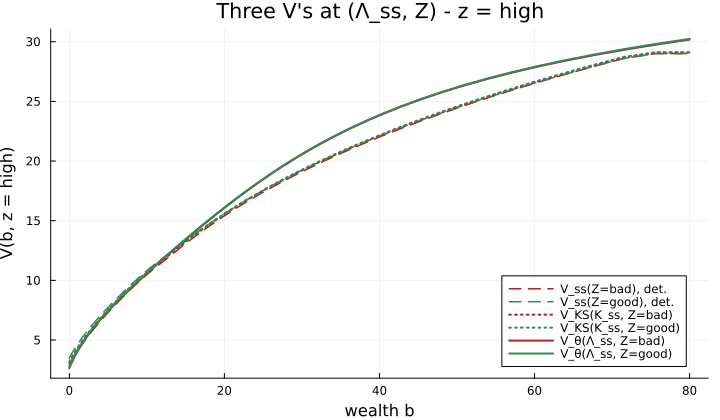

In [17]:
# K-S helpers (mirrored from L07). Self-contained so this notebook can be re-run alone.

"Five-stage K-S behavioural household with state (b, z, Z_idx, K) and ALM-driven K."
function behavioural_alm_household(p::KSParams)
    layout = StateLayout(
        StateAxis(:wealth, continuous_grid(p.b_min, p.b_max; length=p.N_b, spacing=:log)),
        StateAxis(:z,      p.z_grid),
        StateAxis(:Z_idx,  [1, 2]),
        StateAxis(:K,      continuous_grid(p.K_min, p.K_max; length=p.N_K)),
    )
    z_shock  = MarkovStage(layout; axis=:z, transition=p.Π_z)
    income   = WealthChangeStage(layout; wealth_post=(cell; env) -> begin
        Z = p.Z_vals[cell.Z_idx]; (;R, w) = ks_prices(cell.K, Z, p); min(R*cell.wealth + w*cell.z, p.b_max)
    end)
    savings  = ConsumptionSavingsStage(layout; β=p.β, utility=(cell, c; env) -> u_crra(c, Val(p.γ)), monotone_search=:divide_conquer)
    K_evolve = WealthChangeStage(layout; wealth_axis=:K, wealth_post=(cell; env) -> exp(env.a0[cell.Z_idx] + env.a1[cell.Z_idx]*log(cell.K)))
    Z_shock  = MarkovStage(layout; axis=:Z_idx, transition=p.Π_Z)
    chain = z_shock ∘ income ∘ savings ∘ K_evolve ∘ Z_shock
    return define_moments!(chain; K_supplied=at_end(integrand=:wealth, reduce=sum))
end

function K_neighbours(K_grid::AbstractVector, K_t)
    K_c = clamp(K_t, K_grid[1], K_grid[end])
    i_hi = findfirst(>=(K_c), K_grid)
    i_hi == 1 && return (1, 1, 1.0)
    i_lo = i_hi - 1
    w_lo = (K_grid[i_hi] - K_c) / (K_grid[i_hi] - K_grid[i_lo])
    return (i_lo, i_hi, w_lo)
end

function ks_simulate_step(hh_4d, p::KSParams, Λ_2d::AbstractMatrix, Z_idx::Int, K_t)
    K_grid = axisvalues(input_layout(hh_4d).axes[4])
    i_lo, i_hi, w_lo = K_neighbours(K_grid, K_t)
    N_b, N_z = size(Λ_2d); N_Z, N_K = length(p.Z_vals), length(K_grid)
    Λ_4d = zeros(N_b, N_z, N_Z, N_K)
    for j in 1:N_z, i in 1:N_b
        m = Λ_2d[i, j]; iszero(m) && continue
        Λ_4d[i, j, Z_idx, i_lo] += m * w_lo
        i_lo != i_hi && (Λ_4d[i, j, Z_idx, i_hi] += m * (1 - w_lo))
    end
    return dropdims(sum(forward!(hh_4d, Λ_4d); dims=(3, 4)); dims=(3, 4))
end

function ks_simulate(hh_4d, p::KSParams; T=2000, Λ_init, Z_init=1, rng=MersenneTwister(42))
    b_grid = axisvalues(input_layout(hh_4d).axes[1])
    Λ = copy(Λ_init); Z_idx = Z_init
    K_path = zeros(T); Z_idx_path = zeros(Int, T)
    for t in 1:T
        K_t = sum(b_grid .* sum(Λ; dims=2))
        K_path[t] = K_t; Z_idx_path[t] = Z_idx
        Λ = ks_simulate_step(hh_4d, p, Λ, Z_idx, K_t)
        Z_idx = sample_Z(Z_idx, p.Π_Z, rng)
    end
    return (; K_path, Z_idx_path)
end

function regress_ALM(K_path, Z_idx_path, z_idx, window)
    rows = [t for t in window if Z_idx_path[t] == z_idx]
    x = log.(K_path[rows]); y = log.(K_path[rows .+ 1])
    x̄, ȳ = mean(x), mean(y)
    a1 = sum((x .- x̄) .* (y .- ȳ)) / sum((x .- x̄).^2)
    return (; a0 = ȳ - a1*x̄, a1)
end

"K-S outer loop. Returns (a0, a1, V_KS, hh_4d) — V_KS has shape (N_b, N_z, N_Z, N_K)."
function ks_iterate(p::KSParams, K_bar, Λ_0; update_speed=0.5, rtol=1e-3, maxiter=20, T_sim=2000, T_burn=500)
    hh_4d = behavioural_alm_household(p)
    a0 = [log(K_bar), log(K_bar)]; a1 = [0.0, 0.0]
    local V_KS
    err = Inf; iters = 0
    while err >= rtol
        env = make_env(hh_4d; a0, a1)
        res = solve_steady_state_given_env!(hh_4d, env; lambda_tol=1e-7, lambda_maxiter=2_000_000)
        V_KS = res.V
        sim = ks_simulate(hh_4d, p; T=T_sim, Λ_init=Λ_0, Z_init=1)
        wf = (T_burn + 1):(T_sim - 1)
        fb = regress_ALM(sim.K_path, sim.Z_idx_path, 1, wf)
        fg = regress_ALM(sim.K_path, sim.Z_idx_path, 2, wf)
        a0_new = [fb.a0, fg.a0]; a1_new = [fb.a1, fg.a1]
        err = maximum(abs.(vcat(a0_new .- a0, a1_new .- a1)))
        a0 = (1 - update_speed) .* a0 .+ update_speed .* a0_new
        a1 = (1 - update_speed) .* a1 .+ update_speed .* a1_new
        iters += 1
        iters > maxiter && error("ks_iterate did not converge in $maxiter iterations")
    end
    return (; a0, a1, V_KS, hh_4d)
end

println("Running K-S outer iteration...")
@time res_ks = ks_iterate(p, K_bar, Λ_ss)
@printf "Converged ALM:\n  Z = bad : log K' = %+.4f + %+.4f log K\n  Z = good: log K' = %+.4f + %+.4f log K\n" res_ks.a0[1] res_ks.a1[1] res_ks.a0[2] res_ks.a1[2]

# Linear-interpolate V_KS in K at K_ss = K(Λ_ss). Result: (N_b, N_z, N_Z).
K_ss   = integrate_K(hh, Λ_ss)
K_grid = axisvalues(input_layout(res_ks.hh_4d).axes[4])
i_lo, i_hi, w_lo = K_neighbours(K_grid, K_ss)
V_KS_at_Kss = w_lo .* res_ks.V_KS[:, :, :, i_lo] .+ (1 - w_lo) .* res_ks.V_KS[:, :, :, i_hi]
@printf "K(Λ_ss) = %.3f, interpolated between K[%d]=%.2f (weight %.3f) and K[%d]=%.2f\n" K_ss i_lo K_grid[i_lo] w_lo i_hi K_grid[i_hi]

# Quantitative deltas at z = high.
V_θ_bad   = vnet(Λ_ss, 1, p)[:, end]
V_θ_good  = vnet(Λ_ss, 2, p)[:, end]
V_KS_bad  = V_KS_at_Kss[:, end, 1]
V_KS_good = V_KS_at_Kss[:, end, 2]
rms(x)    = sqrt(mean(x.^2))
@printf "\nat z = high:\n"
@printf "  |V_θ - V_KS| (Z=bad) : mean = %+.4f, rms = %.4f, max = %.4f\n" mean(V_θ_bad  .- V_KS_bad)  rms(V_θ_bad  .- V_KS_bad)  maximum(abs.(V_θ_bad  .- V_KS_bad))
@printf "  |V_θ - V_KS| (Z=good): mean = %+.4f, rms = %.4f, max = %.4f\n" mean(V_θ_good .- V_KS_good) rms(V_θ_good .- V_KS_good) maximum(abs.(V_θ_good .- V_KS_good))
@printf "  V_KS Z-gap (good-bad): mean = %+.4f, max = %+.4f\n" mean(V_KS_good .- V_KS_bad) maximum(V_KS_good .- V_KS_bad)
@printf "  V_θ  Z-gap (good-bad): mean = %+.4f, max = %+.4f\n" mean(V_θ_good  .- V_θ_bad)  maximum(V_θ_good  .- V_θ_bad)

plt = plot(; xlabel="wealth b", ylabel="V(b, z = high)",
           title="Three V's at (Λ_ss, Z) - z = high",
           size=(720, 420), legend=:bottomright)
plot!(plt, b_grid, V_ss_per_Z[1][:, end];  lw=1.5, color=:firebrick, ls=:dash, label="V_ss(Z=bad), det.")
plot!(plt, b_grid, V_ss_per_Z[2][:, end];  lw=1.5, color=:seagreen,  ls=:dash, label="V_ss(Z=good), det.")
plot!(plt, b_grid, V_KS_bad;  lw=2, color=:firebrick, ls=:dot, label="V_KS(K_ss, Z=bad)")
plot!(plt, b_grid, V_KS_good; lw=2, color=:seagreen,  ls=:dot, label="V_KS(K_ss, Z=good)")
plot!(plt, b_grid, V_θ_bad;   lw=2, color=:firebrick,           label="V_θ(Λ_ss, Z=bad)")
plot!(plt, b_grid, V_θ_good;  lw=2, color=:seagreen,            label="V_θ(Λ_ss, Z=good)")
plt

### 4.11 Sanity checks

$V_\theta$ is the fixed point of the operator $\mathcal{L}$ built from $V_\theta$ itself; the only training signal is the residual $\lVert V_\theta - \mathcal{L} V_\theta\rVert^2$. It is **not** fit to any external value function:

- **$V_{\mathrm{ss}}$ (deterministic Aiyagari SS, per $Z$) is _not_ a target.** It is a different model — permanent $Z$, each solved at its own market-clearing $K$. It appears only as the pretraining warm-start (§4.6) and a rough visual reference; $V_\theta$ should *not* match it at the tails (the capital-channel crossing).
- **$V_{\mathrm{KS}}$ (Krusell-Smith ALM value) is _not_ a target.** It is a different, boundedly-rational solution (log-linear $K$ forecast). $V_\theta$ differing from it is expected, not a failure.

So we validate $V_\theta$ against properties it must satisfy on economic grounds, with no reference solution.

**The benchmark $\bar V(Z)$ (used in check 5).** $\bar V_{\text{bad}}, \bar V_{\text{good}}$ are the values of an agent facing the *fixed* prices `ks_prices(K(Λ_ss), Z)` with the aggregate state frozen at $Z$. This has a clean economic meaning: it is the competitive value of a **measure-zero sub-population permanently in aggregate state $Z$, in a world whose capital $K$ is pinned by a measure-one population in a _different_ $Z$** (the $Z=1$ world that sets $K(\Lambda_{ss})$). Because the sub-population is measure zero it does not move aggregate $K$, so there is no market-clearing condition to violate — it is a genuine price-taking value, exactly the kind $V_\theta$ itself is. Holding $K$ *common* across both $Z$'s removes the capital-channel confound that makes the $V_{\mathrm{ss}}$ curves cross; at fixed $K$, good $Z$ strictly dominates bad $Z$, so the bracket is well-ordered.

**Implemented below:**
1. **Increasing in wealth $b$** — more assets ⇒ higher value.
2. **Concave in $b$** — diminishing marginal value of wealth (CRRA); $\partial V/\partial b$ decreasing.
3. **Increasing in own productivity $z$** — $V_\theta(b, z_{\text{high}}) > V_\theta(b, z_{\text{low}})$.
4. **Increasing in aggregate $Z$** — $V_\theta(\Lambda_{ss}, \text{good}) > V_\theta(\Lambda_{ss}, \text{bad})$ at every $(b,z)$. (Watch the high-$b$ tail.)
5. **Permanent-$Z$ bracket** — $\bar V_{\text{bad}} \le V_\theta(\Lambda_{ss}, \text{bad}) \le V_\theta(\Lambda_{ss}, \text{good}) \le \bar V_{\text{good}}$, up to a small capital-fluctuation slack at the high-$b$ tail.

**Further diagnostics, not implemented here** (natural next steps beyond a first lesson):
- **Euler-equation residuals** — the standard *quantitative* accuracy metric: take $V_\theta$'s savings policy and measure how well $u'(c) = \beta\,\mathbb{E}[R'\,u'(c')]$ holds, reported as $\log_{10}$ errors in consumption units. The cleanest accuracy number, but it requires extracting the policy and interpolating it at off-grid assets.
- **Approximate-aggregation invariance** — perturb $\Lambda$ holding $K(\Lambda)$ fixed; $V_\theta$ should barely move, since the architecture summarizes $\Lambda$ through a low-dimensional generalized moment. Tests whether the network invents spurious dependence on $\Lambda$ beyond $K$.
- **Den Haan dynamic accuracy** — simulate $K$ forward under $V_\theta$'s *own* policy and check it mean-reverts around $K_{ss}$ without drift or explosion; the dynamic counterpart to the static checks above.

In [18]:
# Sanity checks on the trained V_θ at Λ_ss. Each prints PASS/FAIL with the worst-case
# magnitude. No external value function is used as a target (see §4.11).
b_grid = axisvalues(input_layout(hh).axes[1])
Vθ     = [Float64.(vnet(Λ_ss, Z, p)) for Z in 1:N_Z]   # Vθ[Z][b_i, z_j];  Z: 1=bad, 2=good

report(name, ok, detail) = @printf "  [%s] %-40s %s\n" (ok ? "PASS" : "FAIL") name detail
println("Sanity checks on V_θ(Λ_ss, ·):\n")

# 1. Increasing in own wealth b:  ∂V/∂b > 0
dV = minimum(minimum(diff(Vθ[Z][:, j])) for Z in 1:N_Z, j in 1:N_z)
report("1. increasing in wealth b", dV > 0, @sprintf("min Δ_b V = %+.4f", dV))

# 2. Concave in b:  marginal value dV/db is decreasing (Δ(dV/db) ≤ 0, up to numerical wiggle)
d2 = maximum(maximum(diff(diff(Vθ[Z][:, j]) ./ diff(b_grid))) for Z in 1:N_Z, j in 1:N_z)
report("2. concave in b (dV/db decreasing)", d2 <= 1e-2, @sprintf("max Δ(dV/db) = %+.4e", d2))

# 3. Increasing in own productivity z:  V(z_high) > V(z_low)
gz = minimum(minimum(Vθ[Z][:, end] .- Vθ[Z][:, 1]) for Z in 1:N_Z)
report("3. increasing in own z (high>low)", gz > 0, @sprintf("min [V(z_hi) − V(z_lo)] = %+.4f", gz))

# 4. Increasing in aggregate Z at fixed Λ:  V(Λ_ss, good) > V(Λ_ss, bad)
gZ  = Vθ[2] .- Vθ[1]                       # good − bad over all (b, z)
ci  = argmin(gZ)
report("4. increasing in aggregate Z", minimum(gZ) > 0,
       @sprintf("min [V(good) − V(bad)] = %+.4f  at b=%.1f, z=%s", minimum(gZ), b_grid[ci[1]], ci[2]==N_z ? "hi" : "lo"))

# 5. Permanent-Z bracket at fixed K:  V̄_bad ≤ V_θ(bad) ≤ V_θ(good) ≤ V̄_good
#    V̄(Z) = value of a measure-zero sub-pop permanently in Z, at the common K(Λ_ss).
K_ss = integrate_K(hh, Λ_ss)
V̄ = [solve_steady_state_given_env!(hh, make_env(hh; ks_prices(K_ss, p.Z_vals[Z], p)...);
                                    V_init=nothing, Λ_init=nothing,
                                    lambda_tol=1e-7, lambda_maxiter=2_000_000).V for Z in 1:N_Z]
lo = minimum(Vθ[1] .- V̄[1])                # V_θ(bad)  − V̄_bad  ≥ 0 ?
hi = minimum(V̄[2] .- Vθ[2])                # V̄_good   − V_θ(good) ≥ 0 ?
report("5a. V_θ(bad)  ≥ V̄_bad",  lo > 0, @sprintf("min gap = %+.4f", lo))
report("5b. V_θ(good) ≤ V̄_good", hi > 0, @sprintf("min gap = %+.4f", hi))

Sanity checks on V_θ(Λ_ss, ·):

  [PASS] 1. increasing in wealth b                min Δ_b V = +0.0906
  [PASS] 2. concave in b (dV/db decreasing)       max Δ(dV/db) = -5.4135e-03
  [PASS] 3. increasing in own z (high>low)        min [V(z_hi) − V(z_lo)] = +0.2097
  [PASS] 4. increasing in aggregate Z             min [V(good) − V(bad)] = +0.0013  at b=22.8, z=lo
  [FAIL] 5a. V_θ(bad)  ≥ V̄_bad                    min gap = -0.2589
  [FAIL] 5b. V_θ(good) ≤ V̄_good                   min gap = -1.5082


## 5. Extension idea: a monotone, shape-anchored $V_\theta$

The network above outputs $V_\theta(b, z; \Lambda, Z)$ directly, so it must learn the entire *level and shape* of the value function — even though §4.6 already shows us what a sensible value surface looks like. Most of that shape is not the interesting part; what we actually want the network to capture is how $V_\theta$ *deviates* from a known shape as $(\Lambda, Z)$ move.

A cleaner parameterization builds $V_\theta$ as a **shape-anchored increment** over the deterministic $V_{\mathrm{ss,good}}$. Let the network return a matrix $\mathrm{NN}(\Lambda, Z)$ — one column per $z$ — and accumulate *positive* multiples of the known $V_{\mathrm{ss,good}}$ increments along the wealth grid:

$$V_\theta[i, z] \;=\; V_\theta[i-1, z] \;+\; \mathrm{softplus}\!\big(\mathrm{NN}[i, z]\big)\,\cdot\,\big(V_{\mathrm{ss,good}}[i, z] - V_{\mathrm{ss,good}}[i-1, z]\big),$$

with the base level $V_\theta[1, z]$ supplied by a separate output (a "level head").

**Why this helps.**

- **Monotonicity in $b$ for free.** $\mathrm{softplus}(\cdot) > 0$ and $V_{\mathrm{ss,good}}$ is increasing in $b$, so every increment of $V_\theta$ is positive *by construction* — sanity check 1 can never fail, regardless of training. The network can rescale the local slope but never flip its sign.
- **The network learns a normalized, dimensionless quantity.** $\mathrm{softplus}(\mathrm{NN}[i, z])$ is the *ratio* of $V_\theta$'s local slope to $V_{\mathrm{ss,good}}$'s. If $V_\theta$ had exactly the $V_{\mathrm{ss,good}}$ shape, the network would output a constant ($\mathrm{softplus} = 1$); it only has to represent *departures* from that shape. That is a far better-conditioned learning problem than reproducing a value surface spanning $[10, 40]$, and it targets precisely the thing we care about — the deviation — rather than the bulk shape.
- **It directly attacks the level offset.** The level head sets $V_\theta$'s overall level *directly*, instead of relaxing it slowly through the Bellman iteration — which is where the level transient observed in §4.10 came from. Learning slope-ratios near $1$ is also a gentler objective than learning $V$ from a generic initialization: likely faster and steadier.

**What it does not do, and one distinction worth keeping.**

- It guarantees **only** $b$-monotonicity. Concavity (check 2), monotonicity in own $z$ (3) and in $Z$ (4), and the bracket (5) are still left to training — a varying $\mathrm{softplus}(\mathrm{NN})$ can still bend $V_\theta$ non-concave.
- $V_{\mathrm{ss,good}}$ here is a fixed *architectural basis*, **not** a training target. The loss is unchanged: the only signal is still the outer Bellman residual $\lVert V_\theta - \mathcal{L} V_\theta\rVert^2$. $V_{\mathrm{ss,good}}$ enters as a coordinate system — a set of positive basis increments — that $V_\theta$ is expressed *in*, not a value $V_\theta$ is fit *toward*. The network remains free to make $V_\theta$ deviate arbitrarily in slope magnitude; it simply cannot make it non-monotone. This is the same line we have held throughout — $V_{\mathrm{ss}}$ informs the *representation*, never the *objective* — drawn one notch differently.
- It couples $V_\theta$'s slope profile to $V_{\mathrm{ss,good}}$'s: where the anchor is nearly flat (the top of the grid), $V_\theta$ is pushed flat too unless the network outputs a large multiplier. Benign here, since both surfaces are smooth, increasing, and concave, but it is a genuine inductive bias.

The construction is fully differentiable — a `cumsum` of $\mathrm{softplus}(\mathrm{NN}) \odot \mathrm{diff}(V_{\mathrm{ss,good}})$ — so it drops into the existing training loop with no other change. It is an instance of a general trick: *learning in a shape-restricted, prior-anchored basis* instead of in raw output space, trading a small architectural commitment for guaranteed monotonicity and an easier optimization.

### 5.1 Implementation

Below is the shape-anchored architecture. Thanks to the `AbstractVNet` supertype, it is a *pure architecture swap*: the same `pretrain_to_ss!`, `lookahead`, `sample_ergodic`, `train!`, and the five sanity checks all operate on it unchanged — they only ever call `net(Λ, Z_idx, p)`.

The fixed anchor is the good-$Z$ deterministic SS, $V_{\mathrm{ss,good}}$. Its strictly-positive wealth increments $\Delta_b V_{\mathrm{ss,good}}$ are the basis $V_\theta$ is expressed in; they enter the *representation*, never the loss.

In [19]:
# The good-Z deterministic SS is the fixed shape anchor — a coordinate system, NOT a
# training target. Its wealth-increments are the basis V_θ is built in. The clamp (§4)
# flattens V_ss,good over the top, near-empty grid node (cash > b_max ⇒ dV/db = 0 there),
# so we floor the increments at a small ε > 0 to keep the basis strictly positive — that
# is what lets the softplus·Δ construction guarantee *strict* b-monotonicity.
const V_SS_GOOD   = Float32.(V_ss_per_Z[2])               # (N_b, N_z)   good-Z Aiyagari SS
const ANCHOR_INCR = max.(diff(V_SS_GOOD; dims=1), 1f-3)   # (N_b-1, N_z) strictly positive basis
@assert all(ANCHOR_INCR .> 0)

"""CLAUDE
Shape-anchored value network (§5). Identical GM front end to `VNet`, but the output is a
cumulative sum of *positive* multiples of the fixed good-Z SS increments:

    V_θ[i,z] = level[z] + Σ_{2≤k≤i} softplus(NN[k,z]) · ANCHOR_INCR[k-1,z],

so V_θ is monotone in b *by construction* (softplus > 0, anchor increasing). `slope_head`
emits the per-cell slope-ratio logits NN[i,z]; `level_head` sets the base value V_θ[1,z]
directly from the Λ-embedding and Z. The anchor enters only as a basis (the consts above).
"""
struct ShapeVNet{A, P, G, S, L} <: AbstractVNet
    pop_agg_net :: A    # (b,z) → gm_dim       per-cell embedding for GM
    V_pre       :: P    # (b,z) → mid          per-cell features for the slope head
    gm_post     :: G    # gm_dim → mid         project GM to mid space
    slope_head  :: S    # mid + N_Z → 1        per-cell slope-ratio logit NN[i,z]
    level_head  :: L    # gm_dim + N_Z → N_z   base level V_θ[1,z]
end

Flux.@layer ShapeVNet

function ShapeVNet(; gm_dim=16, mid=32, seed=9483)
    seed!(seed)
    pop_agg_net = Chain(Dense(2 => mid, swish), Dense(mid => mid, swish), Dense(mid => gm_dim))
    V_pre       = Chain(Dense(2 => mid, swish), Dense(mid => mid, swish), Dense(mid => mid, swish))
    gm_post     = Chain(Dense(gm_dim => mid), Dense(mid => mid, swish))
    slope_head  = Chain(Dense(mid + N_Z => mid, swish), Dense(mid => mid, swish), Dense(mid => 1))
    level_head  = Chain(Dense(gm_dim + N_Z => mid, swish), Dense(mid => N_z))
    # Init EXACTLY at the anchor: zero the final-layer weights so each head outputs only its
    # bias. softplus(log(e−1)) = 1 ⇒ every slope-ratio is 1; base level = V_ss,good[1,z]. Then
    # V_θ[i,z] = V_ss,good[i,z] for every (Λ, Z) at init — the net starts by reproducing the
    # anchor and only learns departures from it.
    slope_head.layers[end].weight .= 0f0
    slope_head.layers[end].bias   .= Float32(log(exp(1f0) - 1f0))
    level_head.layers[end].weight .= 0f0
    level_head.layers[end].bias   .= V_SS_GOOD[1, :]
    return ShapeVNet(pop_agg_net, V_pre, gm_post, slope_head, level_head)
end

function (net::ShapeVNet)(Λ::AbstractMatrix, Z_idx::Int, p::KSParams)
    pop_emb = net.pop_agg_net(HH_FEAT)              # (gm_dim, N_CELLS)
    gm      = pop_emb * Float32.(vec(Λ))            # (gm_dim,)   pop-weighted average
    h_pre   = net.V_pre(HH_FEAT)                    # (mid, N_CELLS)
    h_gm    = net.gm_post(gm)                       # (mid,)
    h       = h_pre .+ h_gm                         # (mid, N_CELLS)

    logits  = net.slope_head(vcat(h, Z_ROWS[Z_idx]))    # (1, N_CELLS)
    NN      = reshape(logits, p.N_b, N_z)               # (N_b, N_z)  slope-ratio logits
    z_oh    = Float32.(1:N_Z .== Z_idx)                 # (N_Z,)
    level   = net.level_head(vcat(gm, z_oh))            # (N_z,)  base value at b[1]

    incr    = softplus.(NN[2:end, :]) .* ANCHOR_INCR    # (N_b-1, N_z) > 0 by construction
    Vtail   = cumsum(incr; dims=1)                      # (N_b-1, N_z)
    return reshape(level, 1, N_z) .+ vcat(zeros(Float32, 1, N_z), Vtail)   # (N_b, N_z)
end

shapenet = ShapeVNet()
Vsa0 = shapenet(Λ_ss, 2, p)
@printf "ShapeVNet at init reproduces the anchor (up to the ε-floored top node):\n"
@printf "  max |V_θ,init(Λ_ss, ·) − V_ss,good| = %.3e  (any Λ, Z)\n" maximum(abs.(Vsa0 .- V_SS_GOOD))
@printf "  min Δ_b V at init (monotone ⇔ > 0)  = %+.4f\n" minimum(diff(Vsa0; dims=1))

ShapeVNet at init reproduces the anchor (up to the ε-floored top node):
  max |V_θ,init(Λ_ss, ·) − V_ss,good| = 9.995e-04  (any Λ, Z)
  min Δ_b V at init (monotone ⇔ > 0)  = +0.0010


### 5.2 Train the shape-anchored net

The exact same two-stage pipeline as §4.6–4.8 — pretrain on the $Z$-conditional $V_{\mathrm{ss}}(Z)$, then neural fitted value iteration on the outer Bellman residual — pointed at `shapenet` instead of `vnet`. Nothing in the training code changes.

In [20]:
println("Pretraining ShapeVNet on Z-conditional V_ss(Z)...")
@time pre_hist_sa = pretrain_to_ss!(shapenet, V_ss_per_Z, p; epochs=300)
@printf "Pretrain loss: %.4e → %.4e\n\n" pre_hist_sa[1] pre_hist_sa[end]

train_hist_sa = train!(shapenet, hh, p; epochs=4_000)

Pretraining ShapeVNet on Z-conditional V_ss(Z)...
  7.652508 seconds (13.26 M allocations: 3.734 GiB, 6.70% gc time, 47.93% compilation time)
Pretrain loss: 7.2833e-02 → 2.0527e-04

  epoch    1 / 4000: loss = 2.5127e-03 (batch = 25)
  epoch   50 / 4000: loss = 2.2775e-03 (batch = 25)
  epoch  100 / 4000: loss = 1.7523e-03 (batch = 25)
  epoch  150 / 4000: loss = 1.9577e-03 (batch = 25)
  epoch  200 / 4000: loss = 1.7186e-03 (batch = 25)
  epoch  250 / 4000: loss = 1.5740e-03 (batch = 25)
  epoch  300 / 4000: loss = 1.7723e-03 (batch = 25)
  epoch  350 / 4000: loss = 1.5144e-03 (batch = 25)
  epoch  400 / 4000: loss = 1.3921e-03 (batch = 25)
  epoch  450 / 4000: loss = 1.1279e-03 (batch = 25)
  epoch  500 / 4000: loss = 1.1630e-03 (batch = 25)
  epoch  550 / 4000: loss = 1.0665e-03 (batch = 25)
  epoch  600 / 4000: loss = 7.3956e-04 (batch = 25)
  epoch  650 / 4000: loss = 9.7506e-04 (batch = 25)
  epoch  700 / 4000: loss = 7.7899e-04 (batch = 25)
  epoch  750 / 4000: loss = 7.7755e-04

4000-element Vector{Float64}:
 0.0025126999244093895
 0.002551656449213624
 0.002627966459840536
 0.0024321398232132196
 0.0024246429093182087
 0.002804382471367717
 0.002362111583352089
 0.0025406754575669765
 0.002386972540989518
 0.002432426670566201
 0.0026330396067351103
 0.0024791539181023836
 0.0025061187334358692
 ⋮
 0.00014740944607183337
 9.535083518130705e-5
 0.00010734201350715011
 0.00015803021960891783
 8.77516285981983e-5
 0.0003648697165772319
 0.00010015576845034957
 0.0002149161882698536
 0.00015080424782354385
 0.00012720475206151605
 0.00010404678323538974
 0.00020243485050741583

### 5.3 Loss curves: direct vs shape-anchored

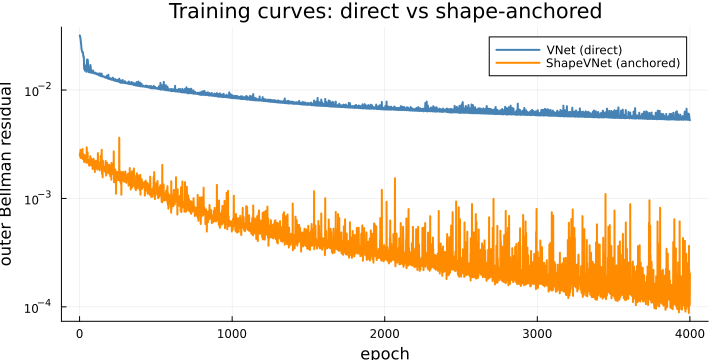

In [21]:
plot(train_hist; yaxis=:log, lw=2, color=:steelblue, label="VNet (direct)",
     xlabel="epoch", ylabel="outer Bellman residual",
     title="Training curves: direct vs shape-anchored",
     size=(720, 360), legend=:topright)
plot!(train_hist_sa; lw=2, color=:darkorange, label="ShapeVNet (anchored)")

### 5.4 Sanity checks: direct vs shape-anchored

The same five checks from §4.11, wrapped in a function and pointed at each net in turn. Check 1 ($b$-monotonicity) is now **structural** for `ShapeVNet` — it cannot fail regardless of training. Checks 2–5 are still left to the optimizer.

In [22]:
"""CLAUDE
Run the five §4.11 economic sanity checks on any AbstractVNet at Λ_ss; print PASS/FAIL per
check. V̄ is the shared permanent-Z bracket benchmark (depends only on K(Λ_ss), not the net).
"""
function sanity_report(net::AbstractVNet, p::KSParams, hh, Λ_ss, V̄)
    b_grid = axisvalues(input_layout(hh).axes[1])
    Vθ = [Float64.(net(Λ_ss, Z, p)) for Z in 1:N_Z]
    report(name, ok, detail) = @printf "  [%s] %-30s %s\n" (ok ? "PASS" : "FAIL") name detail
    dV = minimum(minimum(diff(Vθ[Z][:, j])) for Z in 1:N_Z, j in 1:N_z)
    report("1. increasing in b",        dV > 0,       @sprintf("min Δ_b V = %+.4f", dV))
    d2 = maximum(maximum(diff(diff(Vθ[Z][:, j]) ./ diff(b_grid))) for Z in 1:N_Z, j in 1:N_z)
    report("2. concave in b",           d2 <= 1e-2,   @sprintf("max Δ(dV/db) = %+.4e", d2))
    gz = minimum(minimum(Vθ[Z][:, end] .- Vθ[Z][:, 1]) for Z in 1:N_Z)
    report("3. increasing in own z",    gz > 0,       @sprintf("min gap = %+.4f", gz))
    gZ = minimum(Vθ[2] .- Vθ[1])
    report("4. increasing in aggreg. Z", gZ > 0,      @sprintf("min gap = %+.4f", gZ))
    lo = minimum(Vθ[1] .- V̄[1]); hi = minimum(V̄[2] .- Vθ[2])
    report("5a. V_θ(bad)  ≥ V̄_bad",    lo > 0,       @sprintf("min gap = %+.4f", lo))
    report("5b. V_θ(good) ≤ V̄_good",   hi > 0,       @sprintf("min gap = %+.4f", hi))
end

K_ss = integrate_K(hh, Λ_ss)
V̄ = [solve_steady_state_given_env!(hh, make_env(hh; ks_prices(K_ss, p.Z_vals[Z], p)...);
                                   V_init=nothing, Λ_init=nothing,
                                   lambda_tol=1e-7, lambda_maxiter=2_000_000).V for Z in 1:N_Z]

println("Direct  VNet:");    sanity_report(vnet,     p, hh, Λ_ss, V̄)
println("\nShape-anchored:"); sanity_report(shapenet, p, hh, Λ_ss, V̄)

Direct  VNet:
  [PASS] 1. increasing in b             min Δ_b V = +0.0906
  [PASS] 2. concave in b                max Δ(dV/db) = -5.4135e-03
  [PASS] 3. increasing in own z         min gap = +0.2097
  [PASS] 4. increasing in aggreg. Z     min gap = +0.0013
  [FAIL] 5a. V_θ(bad)  ≥ V̄_bad          min gap = -0.2589
  [FAIL] 5b. V_θ(good) ≤ V̄_good         min gap = -1.5082

Shape-anchored:
  [PASS] 1. increasing in b             min Δ_b V = +0.0010
  [FAIL] 2. concave in b                max Δ(dV/db) = +3.2008e-02
  [PASS] 3. increasing in own z         min gap = +0.1033
  [FAIL] 4. increasing in aggreg. Z     min gap = -0.0112
  [PASS] 5a. V_θ(bad)  ≥ V̄_bad          min gap = +0.0843
  [PASS] 5b. V_θ(good) ≤ V̄_good         min gap = +0.1058


### 5.5 Value functions: direct vs shape-anchored

At $z=$ high, the trained $V_\theta$ from each architecture against the anchor $V_{\mathrm{ss,good}}$.

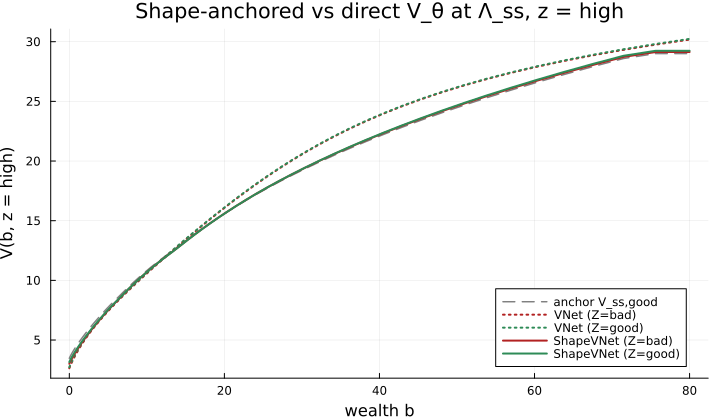

In [23]:
b_grid = axisvalues(input_layout(hh).axes[1])
plt = plot(; xlabel="wealth b", ylabel="V(b, z = high)",
           title="Shape-anchored vs direct V_θ at Λ_ss, z = high",
           size=(720, 420), legend=:bottomright)
plot!(plt, b_grid, V_SS_GOOD[:, end];            lw=1.5, color=:gray,      ls=:dash, label="anchor V_ss,good")
plot!(plt, b_grid, vnet(Λ_ss, 1, p)[:, end];     lw=2,   color=:firebrick, ls=:dot,  label="VNet (Z=bad)")
plot!(plt, b_grid, vnet(Λ_ss, 2, p)[:, end];     lw=2,   color=:seagreen,  ls=:dot,  label="VNet (Z=good)")
plot!(plt, b_grid, shapenet(Λ_ss, 1, p)[:, end]; lw=2,   color=:firebrick,           label="ShapeVNet (Z=bad)")
plot!(plt, b_grid, shapenet(Λ_ss, 2, p)[:, end]; lw=2,   color=:seagreen,            label="ShapeVNet (Z=good)")
plt